# 자율이동체시스템 중간고사 대체 과제

**학번:** 20231328  
**이름:** 김수민  
**사용 데이터:** KITTI Odometry Sequence 09

본 과제에서는 KITTI Odometry Sequence 09의 카메라 영상, calibration 파일, pose 파일을 이용하여 도로 영역 검출과 카메라 투영 과정을 확인하였다. 먼저 Bayesian 기반 도로 분류 코드를 Sequence 09의 grayscale 영상에 적용하여 도로 mask와 overlay 결과를 생성하였다. 이후 projection matrix의 의미를 정리하고, 실제 3D 점을 이미지 좌표로 투영하여 카메라 모델의 특성을 확인하였다. 또한 pose 데이터를 이용하여 차량 궤적을 시각화하고, Bayesian mask에서 얻은 선분 후보와 실패 구간을 분석하였다.

## 목차
0. Bayesian 기반 도로 영역 검출
1. Projection Matrix 해석
2. Projection Matrix를 이용한 3D → 2D 투영
3. Pose를 이용한 차량 궤적 시각화
4. Projection Matrix를 활용한 차선 해석
5. 실패 구간 분석


## 0. Bayesian 기반 도로 영역 검출

Bayesian 도로 분류 예제를 KITTI Sequence 09의 grayscale 영상(`image_0`)에 적용하였다. 도로 영역은 영상 하단에 주로 나타나므로, 소실점 기준의 사다리꼴 ROI를 설정하여 도로 후보 영역과 배경 영역을 나누었다. 각 영역의 밝기 히스토그램을 이용해 도로일 확률을 계산하였고, 프레임이 진행될 때 이전 프레임에서 얻은 밝기 분포도 일부 반영하였다.

이 과정에서 생성된 mask와 overlay 결과를 이후 문제의 선분 후보 확인과 실패 구간 분석에 함께 사용하였다.


In [2]:
import os, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# 경로 설정
SEQ_ID     = "09"
DATA_ROOT  = Path(f"./dataset/sequences/{SEQ_ID}/image_0")
POSE_PATH  = Path(f"./dataset/poses/{SEQ_ID}.txt")
CALIB_PATH = Path(f"./dataset/sequences/{SEQ_ID}/calib.txt")
TIMES_PATH = Path(f"./dataset/sequences/{SEQ_ID}/times.txt")
OUT_DIR    = Path(f"./results/bayes_road_{SEQ_ID}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for name, p in [("image_0", DATA_ROOT), ("poses", POSE_PATH),
                ("calib", CALIB_PATH), ("times", TIMES_PATH)]:
    print(f"{name:10s}: {p} -> {p.exists()}")

frames = sorted(DATA_ROOT.glob('*.png'))
print(f"\n  총 {len(frames)}장 발견")

# Calibration
calib = pd.read_csv(CALIB_PATH, delimiter=' ', header=None, index_col=0)
P0 = np.array(calib.loc['P0:']).reshape(3, 4)
K0, R0, t0_hom, *_ = cv2.decomposeProjectionMatrix(P0)
t0  = (t0_hom / t0_hom[3])[:3]
fx, fy, cx, cy = K0[0,0], K0[1,1], K0[0,2], K0[1,2]

# Poses
poses = pd.read_csv(POSE_PATH, delimiter=' ', header=None)
gt    = np.array([poses.iloc[i].values.reshape(3,4) for i in range(len(poses))])

# Times
times = pd.read_csv(TIMES_PATH, delimiter=' ', header=None)

# 첫 프레임
first_img = np.array(Image.open(frames[0]), dtype=np.uint8)
H, W = first_img.shape
print(f"  이미지 크기 (H, W): ({H}, {W})")
print(f"  P0 fx={fx:.4f}, fy={fy:.4f}, cx={cx:.4f}, cy={cy:.4f}")


image_0   : dataset\sequences\09\image_0 -> True
poses     : dataset\poses\09.txt -> True
calib     : dataset\sequences\09\calib.txt -> True
times     : dataset\sequences\09\times.txt -> True

  총 1591장 발견
  이미지 크기 (H, W): (370, 1226)
  P0 fx=707.0912, fy=707.0912, cx=601.8873, cy=183.1104


### 소실점 기준 ROI 설정

도로는 영상에서 대체로 소실점 아래쪽으로 퍼지는 형태를 가지므로, 소실점을 기준으로 사다리꼴 모양의 ROI를 설정하였다. 이 영역을 도로 후보 영역으로 사용하고, 나머지 영역은 배경 히스토그램을 만들 때 사용하였다.


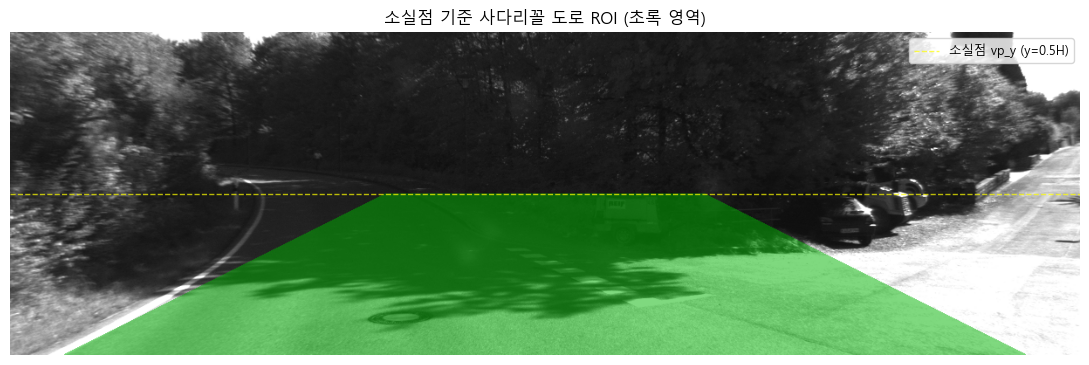

In [3]:
def get_trapezoid_mask(width, height, vp_y_rate=0.5,
                       bottom_width_rate=0.9, top_width_rate=0.15):
    """소실점 기준 사다리꼴 도로 ROI 마스크 생성."""    
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    pts  = np.array([
        [int(width*(0.5-top_width_rate)),  vp_y],
        [int(width*(0.5+top_width_rate)),  vp_y],
        [int(width*(0.5+bottom_width_rate/2)), height],
        [int(width*(0.5-bottom_width_rate/2)), height],
    ], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

road_roi = get_trapezoid_mask(W, H)

fig, ax = plt.subplots(figsize=(11, 4))
overlay_roi = np.stack([first_img]*3, axis=-1)
overlay_roi[road_roi==1] = (overlay_roi[road_roi==1]*0.5 + np.array([0,180,0])*0.5).astype(np.uint8)
ax.imshow(overlay_roi)
ax.axhline(int(H*0.5), color='yellow', lw=1, ls='--', alpha=0.7, label='소실점 vp_y (y=0.5H)')
ax.set_title('소실점 기준 사다리꼴 도로 ROI (초록 영역)')
ax.legend(fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR/'roi_viz.png', dpi=120, bbox_inches='tight')
plt.show()


### Bayesian 분류기 실행

전체 프레임에 대해 도로/배경 밝기 히스토그램을 계산하고, 각 픽셀이 도로에 속할 가능성을 mask로 저장하였다.


In [4]:
def accumulate_histogram(img, mask):
    pixels = img[mask > 0]
    return np.bincount(pixels.flatten(), minlength=256).astype(np.float64)

def classify_frame(img, road_p, bg_p, prior_road=0.5):
    eps = 1e-10
    logit = (np.log(road_p[img]+eps) + math.log(prior_road)
           - np.log(bg_p[img]+eps)   - math.log(1-prior_road))
    prob  = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    return logit > 0, prob

bg_roi       = 1 - road_roi
road_p_total = np.ones(256)
bg_p_total   = np.ones(256)
alpha        = 0.85
save_stride  = 30
road_ratios  = np.zeros(len(frames), dtype=np.float32)

for idx, path in enumerate(frames):
    img = np.array(Image.open(path), dtype=np.uint8)
    rc  = accumulate_histogram(img, road_roi) + 1
    bc  = accumulate_histogram(img, bg_roi)   + 1
    road_p_total = alpha*road_p_total + (1-alpha)*rc if idx else rc
    bg_p_total   = alpha*bg_p_total   + (1-alpha)*bc if idx else bc
    road_p = road_p_total / road_p_total.sum()
    bg_p   = bg_p_total   / bg_p_total.sum()
    mask_pred, prob = classify_frame(img, road_p, bg_p)
    road_ratios[idx] = mask_pred.mean()
    if idx % save_stride == 0:
        stem = path.stem
        Image.fromarray((mask_pred.astype(np.uint8)*255)).save(OUT_DIR/f'mask_{stem}.png')
        Image.fromarray(np.clip(prob*255,0,255).astype(np.uint8)).save(OUT_DIR/f'prob_{stem}.png')
        ov = np.stack([img,img,img], axis=-1)
        ov[mask_pred, 0] = 255
        ov[mask_pred, 1:] = (ov[mask_pred, 1:]*0.3).astype(np.uint8)
        Image.fromarray(ov).save(OUT_DIR/f'overlay_{stem}.png')
    if idx % 200 == 0:
        print(f"  frame {idx:04d}/{len(frames)} | road_ratio={road_ratios[idx]:.3f}")

ratio_df = pd.DataFrame({'frame_idx': np.arange(len(frames)),
                          'frame_name': [p.stem for p in frames],
                          'road_ratio': road_ratios})
ratio_df.to_csv(OUT_DIR/'road_ratios.csv', index=False)
print(f"\n[완료] {len(frames)}프레임 처리, {len(frames)//save_stride}장 저장")


  frame 0000/1591 | road_ratio=0.301
  frame 0200/1591 | road_ratio=0.432
  frame 0400/1591 | road_ratio=0.284
  frame 0600/1591 | road_ratio=0.301
  frame 0800/1591 | road_ratio=0.256
  frame 1000/1591 | road_ratio=0.460
  frame 1200/1591 | road_ratio=0.391
  frame 1400/1591 | road_ratio=0.320

[완료] 1591프레임 처리, 53장 저장


### 도로 검출 결과 확인

생성된 overlay 이미지 중 일부 프레임을 선택하여 원본 영상 위에 도로 mask가 어떻게 표시되는지 확인하였다.


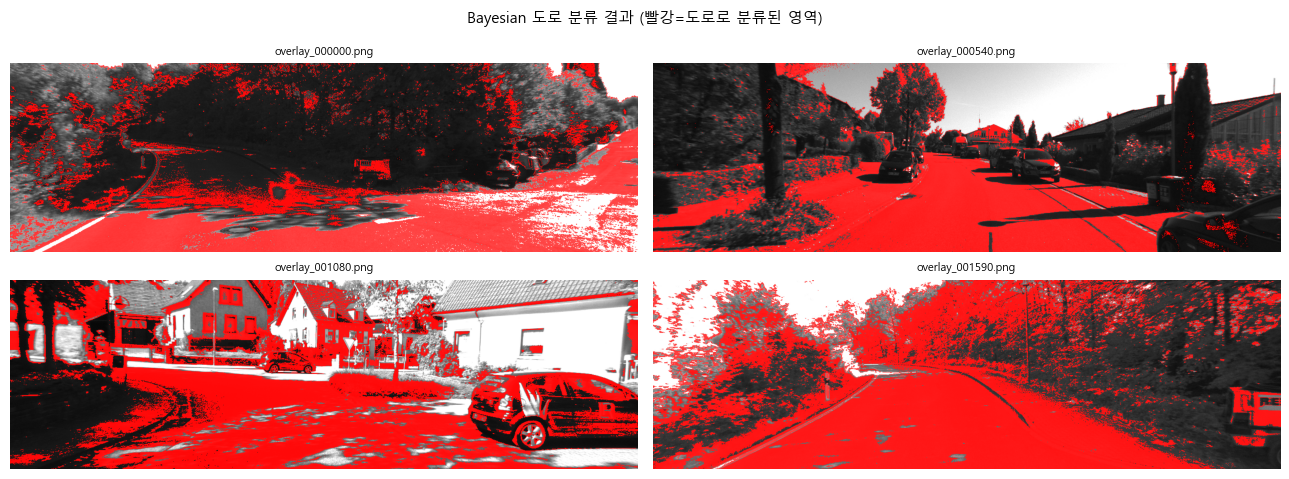

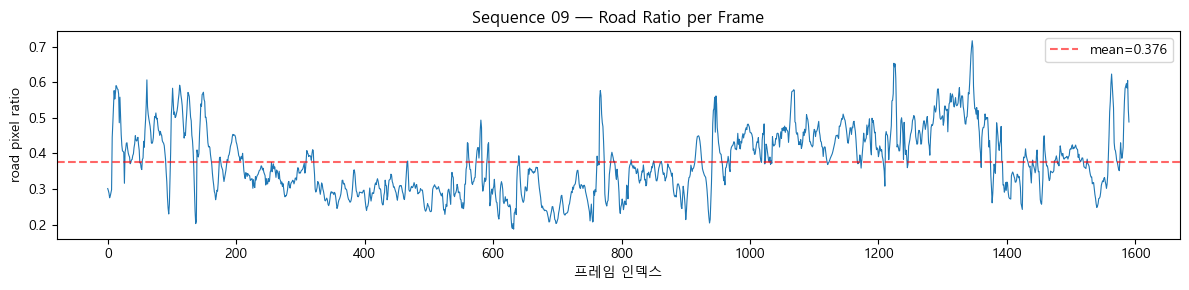

count    1591.000
mean        0.376
std         0.091
min         0.187
25%         0.305
50%         0.365
75%         0.438
max         0.716
Name: road_ratio, dtype: float64


In [5]:
ov_files = sorted(OUT_DIR.glob('overlay_*.png'))
picks = [ov_files[i] for i in [0, len(ov_files)//3,
                                 2*len(ov_files)//3, -1]]
fig, axes = plt.subplots(2, 2, figsize=(13, 5))
for ax, p in zip(axes.flatten(), picks):
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(p.name, fontsize=8)
    ax.axis('off')
plt.suptitle('Bayesian 도로 분류 결과 (빨강=도로로 분류된 영역)', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR/'overview_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(ratio_df.frame_idx, ratio_df.road_ratio, lw=0.8)
plt.axhline(ratio_df.road_ratio.mean(), color='r', ls='--', alpha=0.6,
            label=f"mean={ratio_df.road_ratio.mean():.3f}")
plt.xlabel('프레임 인덱스'); plt.ylabel('road pixel ratio')
plt.title('Sequence 09 — Road Ratio per Frame'); plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'road_ratio_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print(ratio_df.road_ratio.describe().round(3))


---

## 문제 1. Projection Matrix 해석

### 1-1. Projection Matrix의 의미

KITTI의 `calib.txt`에는 각 카메라에 대한 projection matrix가 저장되어 있다. 이번 과제에서 사용하는 `P0`는 왼쪽 흑백 카메라(`image_0`)의 rectified projection matrix이며, 3차원 점을 2차원 이미지 좌표로 변환할 때 사용된다.

카메라 투영은 pinhole camera model로 설명할 수 있고, 기본식은 다음과 같다.

$$s p = K [R|t] P_w$$

여기서 $P_w$는 월드 좌표계의 3D 점, $p$는 이미지 평면의 2D 점이다. $K$는 카메라 내부 파라미터를 나타내고, $[R|t]$는 월드 좌표계의 점을 카메라 좌표계로 바꾸는 역할을 한다. 따라서 projection matrix는 카메라의 초점거리, 주점, 위치, 자세 정보를 이용해 3D 점이 이미지의 어느 픽셀에 나타나는지 계산하는 행렬이라고 볼 수 있다.

본 과제에서는 `P0`를 직접 출력하고, OpenCV의 `decomposeProjectionMatrix()`를 이용하여 내부 파라미터와 회전/이동 성분을 확인하였다.


In [6]:
print("=== Projection Matrix P0 ===")
print(P0)
print("\n=== Intrinsic Matrix K ===")
print(K0.round(4))
print(f"\n  fx = {fx:.4f} px  (x축 초점거리)")
print(f"  fy = {fy:.4f} px  (y축 초점거리)")
print(f"  cx = {cx:.4f} px  (광학중심 x, 이미지 너비 {W}의 절반={W/2:.1f})")
print(f"  cy = {cy:.4f} px  (광학중심 y, 이미지 높이 {H}의 절반={H/2:.1f})")
print("\n=== Extrinsic R, t ===")
print("R ="); print(R0.round(4))
print("t =", t0.round(4).flatten())
print(f"  R == I ? {np.allclose(R0, np.eye(3), atol=1e-6)}")
print(f"  t == 0 ? {np.allclose(t0, 0, atol=1e-6)}")


=== Projection Matrix P0 ===
[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]

=== Intrinsic Matrix K ===
[[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]

  fx = 707.0912 px  (x축 초점거리)
  fy = 707.0912 px  (y축 초점거리)
  cx = 601.8873 px  (광학중심 x, 이미지 너비 1226의 절반=613.0)
  cy = 183.1104 px  (광학중심 y, 이미지 높이 370의 절반=185.0)

=== Extrinsic R, t ===
R =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
t = [0. 0. 0.]
  R == I ? True
  t == 0 ? True


출력된 P0 행렬에서 앞의 3×3 부분은 카메라 내부 파라미터 K에 해당한다. fx와 fy는 픽셀 단위의 초점거리이고, cx와 cy는 이미지 평면에서의 광학 중심 위치를 의미한다. P0의 경우 회전 행렬 R은 단위행렬, 이동 벡터 t는 0으로 나타났으며, 이는 왼쪽 흑백 카메라(image_0)를 기준 좌표계로 사용하기 때문으로 볼 수 있다.

### 1-2. Intrinsic 파라미터와 Extrinsic 파라미터

분해 결과 `P0`의 intrinsic matrix는 다음과 같은 형태로 정리할 수 있다.

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

| 파라미터 | 값 | 의미 |
|---|---:|---|
| $f_x$ | 약 707.09 px | x방향 초점거리 |
| $f_y$ | 약 707.09 px | y방향 초점거리 |
| $c_x$ | 약 601.89 px | 영상의 x방향 광학 중심 |
| $c_y$ | 약 183.11 px | 영상의 y방향 광학 중심 |

$f_x$와 $f_y$가 거의 같기 때문에 x축과 y축의 픽셀 스케일이 거의 동일하다고 볼 수 있다. 또한 $c_x$, $c_y$는 이미지 중심 근처에 있으므로, 카메라의 주점이 영상 중앙 부근에 위치함을 확인할 수 있다.

Extrinsic 파라미터인 $R$과 $t$는 3D 점을 카메라 좌표계로 옮길 때 사용된다. $R$은 카메라가 어느 방향을 보고 있는지를 나타내는 회전 행렬이고, $t$는 좌표계 사이의 이동을 나타내는 벡터이다. KITTI의 rectified camera projection에서는 `P0`가 기준 카메라에 해당하므로, 분해했을 때 회전 행렬은 거의 단위 행렬에 가깝게 나타난다.

### 1-3. 3D 점이 2D 이미지 좌표로 변환되는 과정

3D 점 $X=(X,Y,Z,1)^T$가 있을 때 이미지 좌표는 다음과 같이 계산된다.

$$\lambda \begin{bmatrix}u\\v\\1\end{bmatrix}
= P \begin{bmatrix}X\\Y\\Z\\1\end{bmatrix}
= K[R|t]\begin{bmatrix}X\\Y\\Z\\1\end{bmatrix}$$

먼저 $[R|t]$를 이용하여 월드 좌표계의 점을 카메라 좌표계의 점 $(X_c,Y_c,Z_c)$로 변환한다. 그 다음 깊이값 $Z_c$로 나누어 normalized image coordinate를 만들고, 마지막으로 $K$를 적용하여 픽셀 좌표 $(u,v)$를 얻는다.

$$u = f_x \frac{X_c}{Z_c} + c_x, \quad
v = f_y \frac{Y_c}{Z_c} + c_y$$

이 식에서 $Z_c$가 클수록 $X_c/Z_c$, $Y_c/Z_c$가 작아지므로 점은 광학 중심에 가까워진다. 반대로 카메라에 가까운 점은 이미지에서 더 크게 이동해 보인다.


In [7]:
# 검증: 정면 10m 점은 광학중심에 투영되어야 함
X_test = np.array([[0.0, 0.0, 10.0, 1.0]]).T
uvw = P0 @ X_test
u_t, v_t = uvw[0,0]/uvw[2,0], uvw[1,0]/uvw[2,0]
print(f"정면 10m 점 투영 → (u, v) = ({u_t:.2f}, {v_t:.2f})")
print(f"광학중심 (cx, cy) = ({cx:.2f}, {cy:.2f})")
print(f"일치 여부: u≈cx={np.isclose(u_t,cx,atol=0.1)}, v≈cy={np.isclose(v_t,cy,atol=0.1)}")


정면 10m 점 투영 → (u, v) = (601.89, 183.11)
광학중심 (cx, cy) = (601.89, 183.11)
일치 여부: u≈cx=True, v≈cy=True


---

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

### 2-1. 3D 점 생성, 이미지 좌표 투영 및 시각화

문제 1에서 확인한 `P0`를 이용하여 카메라 좌표계의 3D 점들을 이미지 평면에 투영하였다. OpenCV의 `projectPoints()` 함수도 같은 개념으로 3D object point를 이미지 좌표로 변환할 때 사용되지만, 여기서는 projection matrix의 동작을 직접 확인하기 위해 동차좌표 계산을 코드로 구현하였다.

KITTI 카메라 좌표계에서는 일반적으로 X축은 오른쪽, Y축은 아래쪽, Z축은 전방을 의미한다. 따라서 도로면 위의 점은 카메라보다 아래쪽에 있으므로 $Y$ 값을 양수로 두고, 여러 깊이 $Z$에 대해 점을 배치하였다.

투영 과정에서는 다음 두 가지를 함께 확인하였다.

- 카메라 뒤쪽에 있는 점은 이미지에 투영할 수 없으므로 $Z > 0$인 점만 사용하였다.
- 계산된 $(u, v)$가 이미지 크기 안에 들어오는 경우만 영상 위에 표시하였다.


In [8]:
def project_points(pts_3d, P):
    """(N,3) → (N,2) 픽셀, (N,) 깊이, (N,) 유효 bool"""    
    N   = len(pts_3d)
    pts_h = np.hstack([pts_3d, np.ones((N,1))])  # (N,4)
    uvw   = (P @ pts_h.T).T                       # (N,3)
    dep   = uvw[:,2]
    valid = dep > 0
    uv    = np.zeros((N,2))
    uv[valid] = uvw[valid,:2] / dep[valid,None]
    return uv, dep, valid

pts_labels = ['A: 정면 5m', 'B: 정면 10m', 'C: 정면 20m',
              'D: 정면 40m', 'E: 좌차선 15m', 'F: 우차선 15m',
              'G: 뒤 -5m (불가)']
pts_3d = np.array([
    [ 0.0, 1.65,  5.0],
    [ 0.0, 1.65, 10.0],
    [ 0.0, 1.65, 20.0],
    [ 0.0, 1.65, 40.0],
    [-1.8, 1.65, 15.0],
    [ 1.8, 1.65, 15.0],
    [ 0.0, 1.65, -5.0],
], dtype=float)

uv, depths, valid = project_points(pts_3d, P0)
in_frame = valid & (uv[:,0]>=0)&(uv[:,0]<W)&(uv[:,1]>=0)&(uv[:,1]<H)

print(f"{'점':16s}  {'u(px)':>7s}  {'v(px)':>7s}  {'Z(m)':>6s}  상태")
print('-'*55)
for i, lb in enumerate(pts_labels):
    if not valid[i]:
        print(f"{lb:16s}  {'N/A':>7s}  {'N/A':>7s}  {depths[i]:>6.1f}   Z≤0")
    elif not in_frame[i]:
        print(f"{lb:16s}  {uv[i,0]:>7.1f}  {uv[i,1]:>7.1f}  {depths[i]:>6.1f}  ⚠ 이미지 밖")
    else:
        print(f"{lb:16s}  {uv[i,0]:>7.1f}  {uv[i,1]:>7.1f}  {depths[i]:>6.1f}   유효")


점                   u(px)    v(px)    Z(m)  상태
-------------------------------------------------------
A: 정면 5m            601.9    416.5     5.0  ⚠ 이미지 밖
B: 정면 10m           601.9    299.8    10.0   유효
C: 정면 20m           601.9    241.4    20.0   유효
D: 정면 40m           601.9    212.3    40.0   유효
E: 좌차선 15m          517.0    260.9    15.0   유효
F: 우차선 15m          686.7    260.9    15.0   유효
G: 뒤 -5m (불가)         N/A      N/A    -5.0   Z≤0


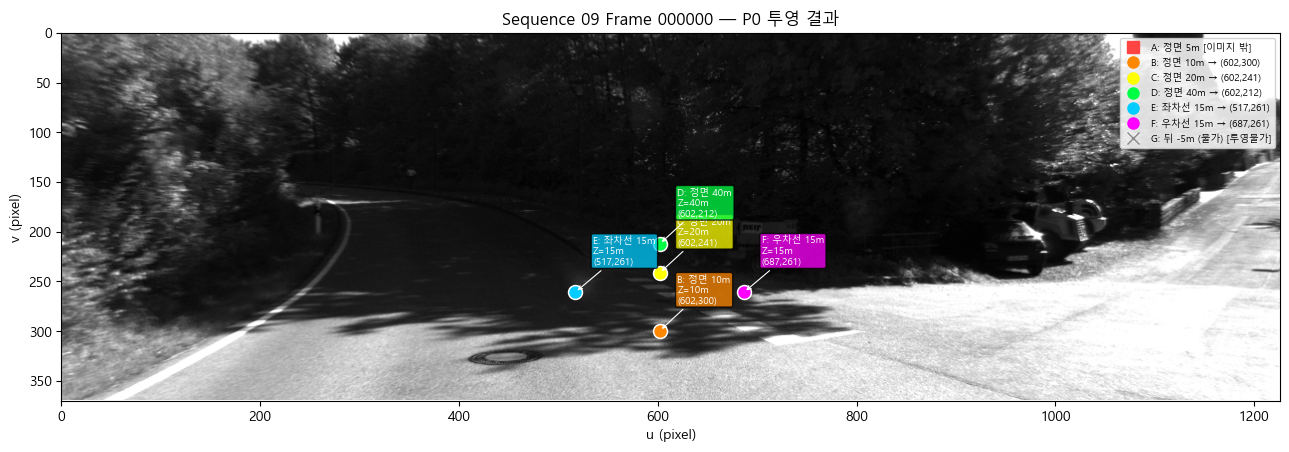

In [9]:
colors = ['#FF4444','#FF8800','#FFFF00','#00FF44','#00CCFF','#FF00FF','#888888']
fig, ax = plt.subplots(figsize=(13,5))
ax.imshow(first_img, cmap='gray')
for i, lb in enumerate(pts_labels):
    if not valid[i]:
        ax.plot([],[],  'x', color=colors[i], ms=9, label=f'{lb} [투영불가]')
        continue
    u_i, v_i = uv[i,0], uv[i,1]
    if in_frame[i]:
        ax.plot(u_i, v_i, 'o', color=colors[i], ms=10,
                markeredgecolor='white', markeredgewidth=1.1)
        ax.annotate(f'{lb}\nZ={depths[i]:.0f}m\n({u_i:.0f},{v_i:.0f})',
                    xy=(u_i,v_i), xytext=(u_i+18, v_i-28), fontsize=7, color='white',
                    arrowprops=dict(arrowstyle='->', color='white', lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.2', fc=colors[i], alpha=0.75))
        ax.plot([],[],  'o', color=colors[i], ms=8, label=f'{lb} → ({u_i:.0f},{v_i:.0f})')
    else:
        ax.plot([],[],'s',color=colors[i],ms=8,label=f'{lb} [이미지 밖]')
ax.set_xlim(0,W); ax.set_ylim(H,0)
ax.set_title('Sequence 09 Frame 000000 — P0 투영 결과')
ax.set_xlabel('u (pixel)'); ax.set_ylabel('v (pixel)')
ax.legend(loc='upper right', fontsize=7, framealpha=0.85)
plt.tight_layout()
plt.savefig(OUT_DIR/'q2_projection_viz.png', dpi=150, bbox_inches='tight')
plt.show()


### 2-2. 투영 결과 해석

투영 결과를 보면 같은 높이의 점이라도 카메라와 가까운 점은 영상 아래쪽에 나타나고, 멀어질수록 광학 중심에 가까워지는 것을 확인할 수 있다. 이는 투영 과정에서 u = fx(X/Z) + cx, v = fy(Y/Z) + cy 형태로 계산되기 때문에, Z가 커질수록 X/Z와 Y/Z의 영향이 작아지기 때문이다.

또한 좌우에 같은 거리로 둔 점들은 $c_x$를 기준으로 거의 대칭적으로 투영되었다. 이를 통해 projection matrix의 $c_x$, $f_x$ 값이 이미지상의 좌우 위치를 결정한다는 것을 확인할 수 있었다.

카메라 뒤쪽에 있는 점은 Z ≤ 0이므로 이미지 평면에 정상적으로 투영할 수 없어 제외하였다. 또한 계산된 픽셀 좌표가 이미지 크기를 벗어나는 경우도 실제 영상 위에는 표시하지 않았다. 따라서 실제 투영 결과를 사용할 때는 깊이 조건과 이미지 경계 조건을 함께 확인해야 한다.

## 문제 3. Pose를 이용한 차량 이동 궤적 시각화

### 3-1. 카메라 위치 추출 및 궤적 시각화

KITTI pose 파일의 각 행은 한 프레임에서의 3×4 카메라 pose 행렬이며, 마지막 열은 평행이동 벡터 $t = (t_x, t_y, t_z)^T$를 의미한다. 따라서 이 값을 각 프레임에서의 차량 또는 카메라 위치로 사용할 수 있다.

본 과제에서는 Sequence 09의 pose 파일에서 각 프레임의 카메라 위치를 추출한 뒤, 첫 번째 프레임의 위치를 모든 프레임에서 빼 주어 시작 지점이 (0, 0, 0)이 되도록 좌표계를 재설정하였다. 이후 X-Z 평면을 이용하여 차량의 이동 궤적을 2D로 시각화하였다. X축은 차량의 좌우 방향, Z축은 전후 방향 이동을 나타낸다.

총 프레임 수: 1591
시작 위치: (0.00, 0.00, 0.00)
마지막 위치: (-3.01, 3.05, 8.22)
총 이동 거리: 1705.1 m (1.71 km)
평균 이동 속도: 10.3 m/s (37.2 km/h)


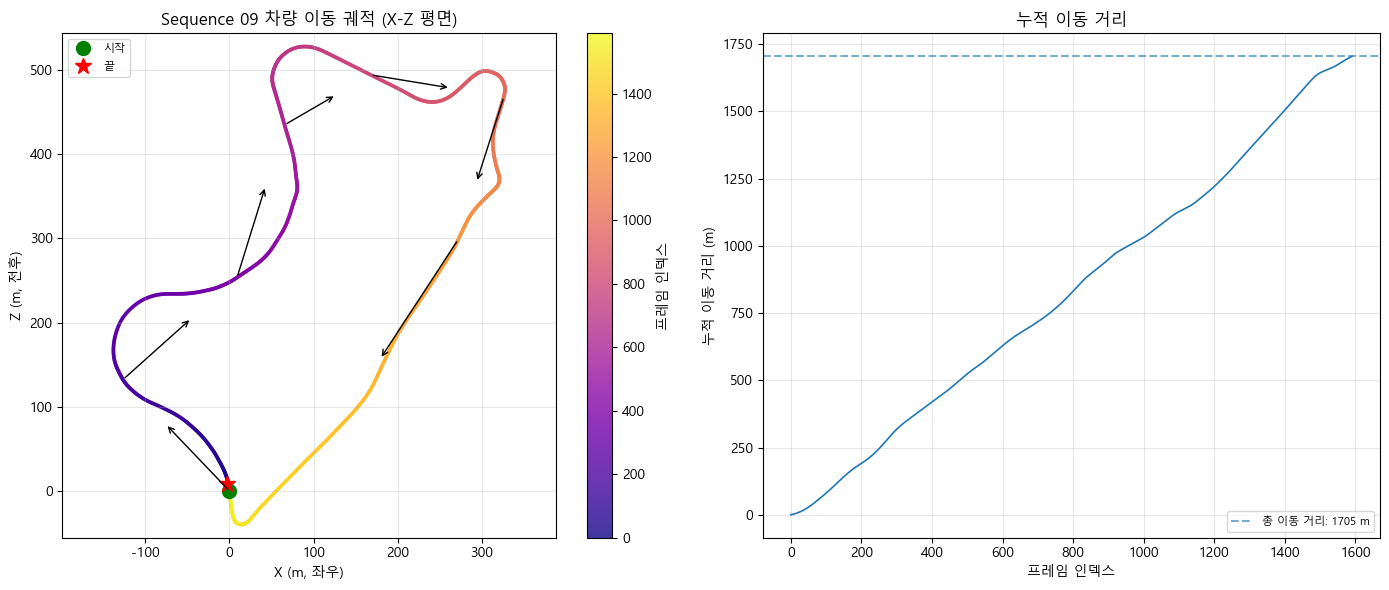

In [24]:
# KITTI pose 데이터를 이용한 차량 이동 궤적 시각화

positions = gt[:, :, 3]   # (N, 3): [tx, ty, tz]

# 초기 프레임을 기준 좌표계로 설정
positions = positions - positions[0]

x_pos = positions[:, 0]
y_pos = positions[:, 1]
z_pos = positions[:, 2]

# 프레임별 이동 거리 및 평균 속도 계산
diffs = np.diff(positions, axis=0)
dist_per_frame = np.linalg.norm(diffs, axis=1)

total_dist = dist_per_frame.sum()
total_time = times.values.flatten()[-1]

avg_speed = total_dist / total_time
avg_speed_kmh = avg_speed * 3.6

print(f"총 프레임 수: {len(positions)}")
print(f"시작 위치: ({x_pos[0]:.2f}, {y_pos[0]:.2f}, {z_pos[0]:.2f})")
print(f"마지막 위치: ({x_pos[-1]:.2f}, {y_pos[-1]:.2f}, {z_pos[-1]:.2f})")
print(f"총 이동 거리: {total_dist:.1f} m ({total_dist / 1000:.2f} km)")
print(f"평균 이동 속도: {avg_speed:.1f} m/s ({avg_speed_kmh:.1f} km/h)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: X-Z 평면 궤적
ax = axes[0]
sc = ax.scatter(
    x_pos,
    z_pos,
    c=np.arange(len(x_pos)),
    cmap='plasma',
    s=3,
    alpha=0.8
)

plt.colorbar(sc, ax=ax, label='프레임 인덱스')

ax.plot(x_pos[0], z_pos[0], 'go', markersize=10, label='시작')
ax.plot(x_pos[-1], z_pos[-1], 'r*', markersize=12, label='끝')

# 이동 방향 화살표 표시
for j in range(0, len(x_pos) - 200, 200):
    dx = x_pos[j + 200] - x_pos[j]
    dz = z_pos[j + 200] - z_pos[j]
    ax.annotate(
        '',
        xy=(x_pos[j] + dx * 0.6, z_pos[j] + dz * 0.6),
        xytext=(x_pos[j], z_pos[j]),
        arrowprops=dict(arrowstyle='->', lw=1.0)
    )

ax.set_xlabel('X (m, 좌우)')
ax.set_ylabel('Z (m, 전후)')
ax.set_title('Sequence 09 차량 이동 궤적 (X-Z 평면)')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 오른쪽: 누적 이동 거리
ax2 = axes[1]
cum_dist = np.concatenate([[0], np.cumsum(dist_per_frame)])

ax2.plot(cum_dist, linewidth=1.2)
ax2.axhline(
    total_dist,
    linestyle='--',
    alpha=0.6,
    label=f'총 이동 거리: {total_dist:.0f} m'
)

ax2.set_xlabel('프레임 인덱스')
ax2.set_ylabel('누적 이동 거리 (m)')
ax2.set_title('누적 이동 거리')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q3_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

### 3-2. 이동 방향 및 속도 해석

시각화 결과, 차량은 초기 위치를 기준으로 전체적으로 전방 방향으로 이동하였으며, 일부 구간에서는 X축 방향의 변화도 함께 나타났다. 이는 차량이 완전히 직선으로만 이동한 것이 아니라 도로의 형태에 따라 좌우 방향으로도 이동했음을 의미한다.

프레임 사이의 위치 차이를 이용해 프레임별 이동 거리를 계산하고, 이를 누적하여 전체 이동 거리를 구하였다. 또한 `times.txt`의 시간 정보를 이용하여 평균 이동 속도를 계산하였다. 누적 이동 거리 그래프에서 기울기가 큰 구간은 프레임당 이동 거리가 큰 구간이므로 상대적으로 빠르게 이동한 구간으로 볼 수 있고, 기울기가 작은 구간은 상대적으로 느리게 이동한 구간으로 볼 수 있다. 따라서 차량의 속도는 일정하지 않고 주행 구간에 따라 변화한 것으로 해석할 수 있다.

---

## 문제 4. Projection Matrix를 활용한 차선 해석

### 4-1. 선분 후보 확인 방법

문제 0에서 생성한 Bayesian 도로 mask를 이용하여 차선이나 도로 경계처럼 보일 수 있는 선분 후보를 찾아보았다. 차선과 도로 경계는 영상에서 대체로 길게 이어지는 선 형태로 나타나므로, 먼저 도로 mask에서 도로와 배경이 나뉘는 부분을 찾고, OpenCV의 직선 검출 함수를 이용하여 선분 후보를 선택하였다.

처리 과정은 다음과 같다.

1. Bayesian 결과로 생성된 도로 mask를 불러온다.
2. mask에서 도로와 배경이 나뉘는 경계 성분을 찾는다.
3. OpenCV의 직선 검출 함수를 이용하여 선 형태로 이어지는 부분을 찾는다.
4. 너무 수평에 가까운 선분이나 도로 영역 밖에 있는 선분은 제외한다.
5. 남은 선분을 원본 영상 위에 표시하고, 도로 평면 위에서의 위치도 함께 확인한다.

이미지 좌표에서 검출된 차선은 단순히 픽셀 위치이지만, projection matrix와 카메라 내부 파라미터를 이용하면 카메라 앞쪽의 어느 방향에 있는 선인지 대략적으로 해석할 수 있다. 이번 과제에서는 도로를 평면으로 가정하고, 카메라 높이를 일정하게 두어 픽셀 좌표를 차량 기준 좌우 위치 $X$와 전방 거리 $Z$로 변환하였다.

$$Z = \frac{f_y h}{v-c_y}, \quad
X = \frac{(u-c_x)Z}{f_x}$$

이 계산은 정확한 3D 복원이라기보다는, 검출된 차선이 차량 앞쪽의 어느 위치에 있는지 확인하기 위한 근사적인 방법이다. 실제 차선은 도로 위에서 거의 평행하지만, 영상에서는 원근감으로 인해 멀리 있는 차선일수록 서로 가까워 보인다. 따라서 차선이 이미지 위에서 소실점 방향으로 모이는 형태로 나타난다. 즉, 영상에서 차선의 기울기와 소실점 위치는 projection matrix가 만드는 원근 투영 결과와 관련이 있다.


선택 프레임: ['mask_000270.png', 'mask_000810.png', 'mask_001350.png']


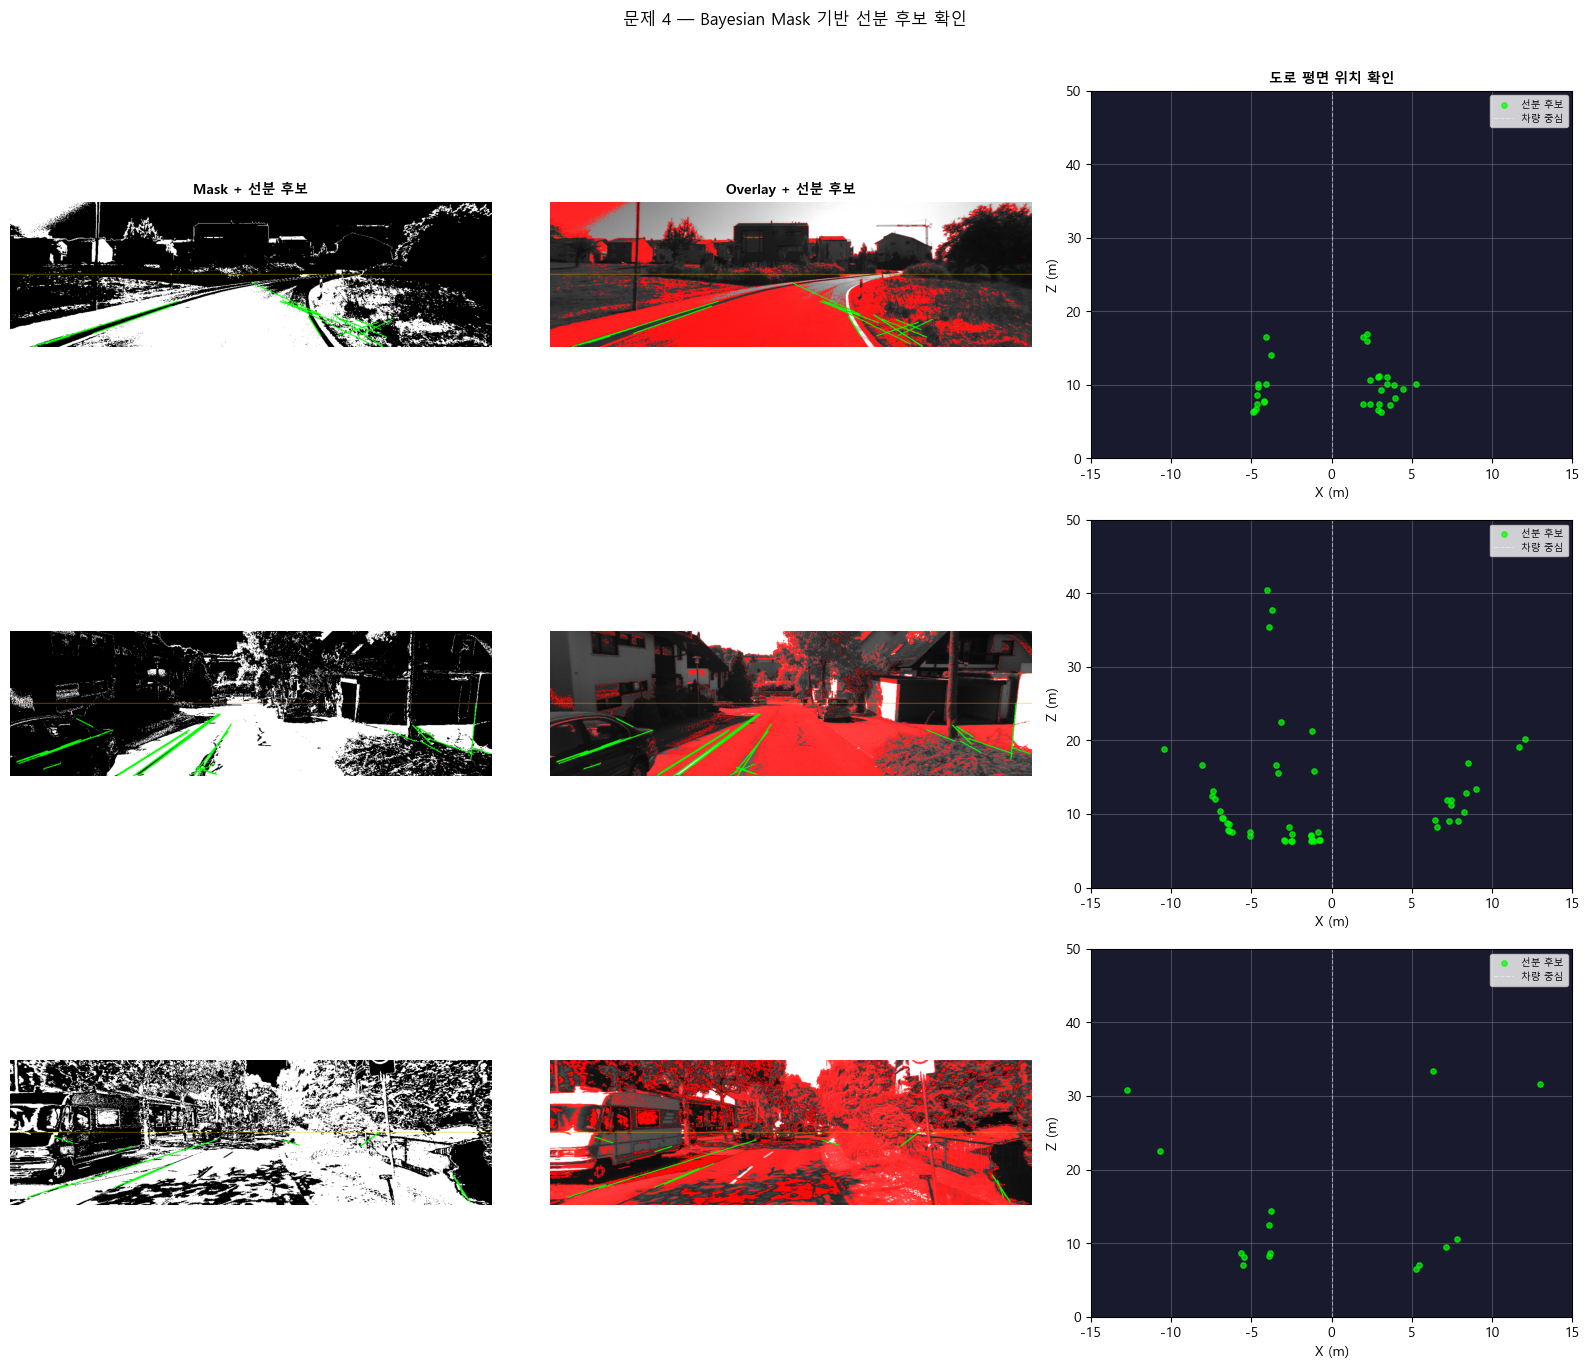

In [12]:
mask_files = sorted(OUT_DIR.glob('mask_*.png'))
n = len(mask_files)
sel = [mask_files[n//6], mask_files[n//2], mask_files[n*5//6]]
print("선택 프레임:", [f.name for f in sel])

def backproject(u, v, fx, fy, cx, cy, h=1.65):
    dv = v - cy
    if abs(dv) < 1e-6: return None
    Z = fy * h / dv
    if Z <= 0: return None
    return (u - cx) * Z / fx, Z

def detect_line_candidates(mask_bin, roi_top_ratio=0.5):
    h, w = mask_bin.shape
    top  = int(h * roi_top_ratio)
    roi  = mask_bin[top:, :]
    edges = cv2.Canny(roi, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 30, minLineLength=40, maxLineGap=20)
    if lines is not None:
        lines[:,:,1] += top; lines[:,:,3] += top
    return lines, top

CAMERA_H = 1.65
fig, axes = plt.subplots(len(sel), 3, figsize=(16, 4.5*len(sel)))
col_titles = ['Mask + 선분 후보', 'Overlay + 선분 후보', '도로 평면 위치 확인']
for c, ct in enumerate(col_titles): axes[0,c].set_title(ct, fontsize=10, fontweight='bold')

for row, mf in enumerate(sel):
    stem   = mf.stem.replace('mask_','')
    ov_p   = OUT_DIR/f'overlay_{stem}.png'
    mask_b = (np.array(Image.open(mf).convert('L'))>127).astype(np.uint8)*255
    overlay= np.array(Image.open(ov_p)) if ov_p.exists() else np.stack([mask_b]*3,-1)
    lines, top = detect_line_candidates(mask_b)

    vis_m = cv2.cvtColor(mask_b, cv2.COLOR_GRAY2BGR)
    vis_o = overlay.copy()
    bev   = []

    if lines is not None:
        for ln in lines:
            x1,y1,x2,y2 = ln[0]
            if abs(x2-x1)<1 or abs((y2-y1)/(x2-x1+1e-9))<0.3: continue
            cv2.line(vis_m,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.line(vis_o,(x1,y1),(x2,y2),(0,255,0),2)
            for u_px, v_px in [(x1,y1),(x2,y2)]:
                pt = backproject(u_px, v_px, fx, fy, cx, cy, CAMERA_H)
                if pt: bev.append(pt)

    cv2.line(vis_m,(0,top),(mask_b.shape[1],top),(255,165,0),1)
    cv2.line(vis_o,(0,top),(overlay.shape[1],top),(255,165,0),1)
    axes[row,0].imshow(vis_m); axes[row,0].set_ylabel(f'frame {stem}',fontsize=8); axes[row,0].axis('off')
    axes[row,1].imshow(vis_o); axes[row,1].axis('off')

    ax_b = axes[row,2]
    if bev:
        bv = np.array(bev)
        ax_b.scatter(bv[:,0], bv[:,1], c='lime', s=15, alpha=0.7, label='선분 후보')
        ax_b.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5, label='차량 중심')
        ax_b.set_xlim(-15,15); ax_b.set_ylim(0,50)
        ax_b.set_xlabel('X (m)'); ax_b.set_ylabel('Z (m)')
        ax_b.legend(fontsize=7); ax_b.grid(True,alpha=0.3)
    ax_b.set_facecolor('#1a1a2e')

plt.suptitle('문제 4 — Bayesian Mask 기반 선분 후보 확인', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR/'q4_lane_backproject.png', dpi=150, bbox_inches='tight')
plt.show()


### 4-2. 선분 후보 결과 해석

OpenCV의 직선 검출 함수를 적용한 결과, Bayesian mask의 경계 부근에서 여러 선분 후보가 나타났다. 이 중 일부는 실제 차선이나 도로 가장자리에 가까운 선분으로 보이고, 일부는 그림자나 차량 주변 경계, 밝기 변화가 같이 잡힌 결과로 보인다.

이미지에서 검출된 선분은 처음에는 픽셀 좌표로만 표현된다. 하지만 카메라의 초점거리와 중심점 값을 이용하면, 이 선분이 차량 기준으로 왼쪽 또는 오른쪽 어느 방향에 있는지 대략적으로 해석할 수 있다. 이번 과제에서는 도로가 평평하다고 가정하고, 검출된 점들을 차량 기준의 좌우 방향과 전방 방향으로 단순 변환하여 확인하였다.

도로를 하나의 평면으로 보면, 실제 차선은 도로 위에서 거의 평행한 선으로 볼 수 있다. 직선 도로에서는 후보 선분들이 비슷한 방향으로 나타났고, 커브가 있는 프레임에서는 후보들의 위치가 조금 휘어진 형태로 보였다.

Projection matrix는 카메라 좌표계의 3D 점을 이미지의 2D 픽셀 좌표로 바꾸는 역할을 한다. 이때 실제 도로 위에서 평행한 차선도 이미지에서는 원근감 때문에 위쪽으로 갈수록 서로 가까워 보이고, 연장하면 한 지점으로 모이는 것처럼 나타난다. 이 지점을 소실점(vanishing point)이라고 볼 수 있다. 따라서 이미지에서 보이는 차선의 기울기와 모이는 방향은 카메라 투영 결과와 관련이 있다.

다만 이 결과는 Bayesian mask가 얼마나 잘 만들어졌는지에 영향을 많이 받았다. 차량이나 건물 일부가 도로로 잘못 분류되면 그 경계도 선분으로 검출될 수 있고, 그림자가 강한 부분에서도 잘못된 선분이 나타날 수 있다. 따라서 이번 결과는 차선의 정확한 위치를 찾는 것보다는, 검출된 선분 후보가 도로 방향과 어느 정도 맞는지 확인하는 용도로 보는 것이 적절하다.

---

## 문제 5. 실패 구간 분석

### 5-1. 실패 구간 선정

Bayesian 기반 도로 분류 결과에서 도로 영역이 실제보다 과하게 검출된 프레임을 실패 구간으로 선택하였다. 실패 구간은 도로가 아예 검출되지 않는 경우뿐만 아니라, 도로가 아닌 영역까지 도로로 잘못 분류되는 경우도 포함한다고 볼 수 있다.

이번 결과에서는 과소 검출(Under-detection)에 해당하는 대표 프레임은 뚜렷하게 확인되지 않았고, 과다 검출(Over-detection)에 해당하는 프레임이 주로 나타났다. 따라서 과다 검출이 발생한 프레임을 차선 및 도로 분류가 잘 되지 않은 구간으로 보고 분석하였다.

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 이미지 경로
IMG_DIR = Path("dataset/sequences/09/image_0")

# under / over 결과가 없을 경우를 대비
if 'under' not in globals():
    under = np.array([], dtype=int)

if 'over' not in globals():
    over = np.array([], dtype=int)

under = np.array(under, dtype=int).ravel()
over = np.array(over, dtype=int).ravel()

print("과소 검출(Under-detection) 후보 개수:", len(under))
print("과다 검출(Over-detection) 후보 개수:", len(over))

# 대표 프레임 선택
under_frames = under[:3].tolist() if len(under) > 0 else []
over_frames = over[:3].tolist() if len(over) > 0 else []

if len(under_frames) == 0:
    print("과소 검출 대표 프레임은 확인되지 않았다.")
else:
    print("과소 검출 대표 프레임:", under_frames)

if len(over_frames) == 0:
    print("과다 검출 대표 프레임은 확인되지 않았다.")
else:
    print("과다 검출 대표 프레임:", over_frames)

과소 검출(Under-detection) 후보 개수: 0
과다 검출(Over-detection) 후보 개수: 8
과소 검출 대표 프레임은 확인되지 않았다.
과다 검출 대표 프레임: [1224, 1225, 1226]


위 결과에서 과소 검출에 해당하는 대표 프레임은 확인되지 않았고, 과다 검출 대표 프레임은 1224, 1226, 1344로 확인하였다. 따라서 본 문제에서는 이 세 프레임을 실패 구간으로 선택하였다.

### 5-2. 실패 구간 프레임 확인

선택한 실패 프레임의 원본 영상을 확인하여 어떤 장면에서 과다 검출이 발생했는지 살펴보았다. 과다 검출은 도로가 아닌 영역이 도로 영역으로 함께 분류된 경우이므로, 실제 도로 주변의 그림자, 차량, 벽면, 밝기 변화 등이 결과에 영향을 주었을 가능성이 있다.

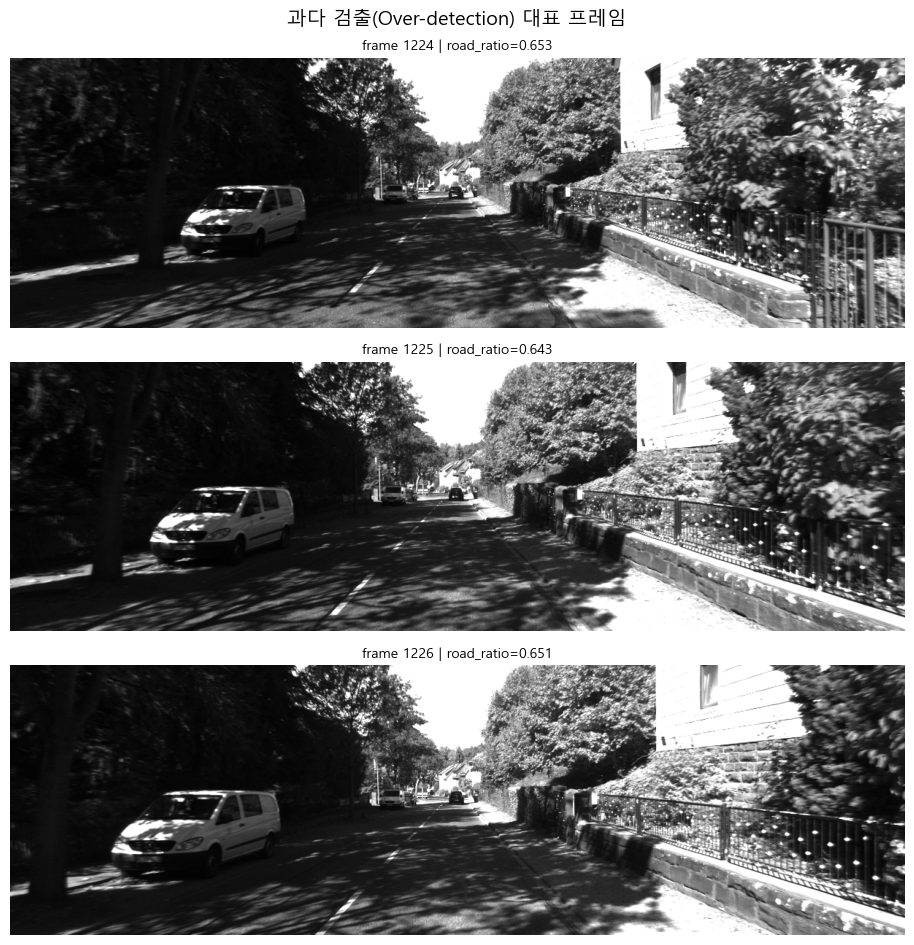

In [26]:
# 과다 검출 대표 프레임 시각화

# 출력 결과가 다르게 나올 경우 직접 지정
if len(over_frames) == 0:
    over_frames = [1224, 1226, 1344]

has_ratio = 'road_ratios' in globals()
if has_ratio:
    road_ratios = np.array(road_ratios, dtype=float).ravel()

fig, axes = plt.subplots(len(over_frames), 1, figsize=(10, 3.2 * len(over_frames)))

if len(over_frames) == 1:
    axes = [axes]

for ax, fi in zip(axes, over_frames):
    img_path = IMG_DIR / f"{fi:06d}.png"

    if not img_path.exists():
        ax.text(0.5, 0.5, f"frame {fi} 이미지 없음", ha="center", va="center")
        ax.axis("off")
        continue

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")

    if has_ratio and fi < len(road_ratios):
        ax.set_title(f"frame {fi} | road_ratio={road_ratios[fi]:.3f}", fontsize=10)
    else:
        ax.set_title(f"frame {fi}", fontsize=10)

    ax.axis("off")

plt.suptitle("과다 검출(Over-detection) 대표 프레임", fontsize=14)
plt.tight_layout()
plt.show()

위 그림은 과다 검출이 발생한 대표 프레임이다. 해당 프레임에서는 도로와 주변 영역의 밝기 차이가 뚜렷하지 않거나, 그림자가 도로 위에 함께 나타난다. 이 경우 Bayesian 분류 과정에서 도로가 아닌 부분도 도로와 비슷한 픽셀 특성을 가진 것으로 판단될 수 있다. 따라서 실제 도로 영역보다 더 넓은 부분이 도로로 검출된 것으로 보인다.

### 5-3. 궤적 상에서 실패 구간 위치 표시

선택한 실패 프레임 번호를 pose 데이터의 프레임 인덱스와 대응시켜 차량 궤적 위에 표시하였다. 이를 통해 차선 및 도로 분류가 잘 되지 않은 프레임이 전체 주행 경로 중 어느 위치에서 발생했는지 확인하였다.

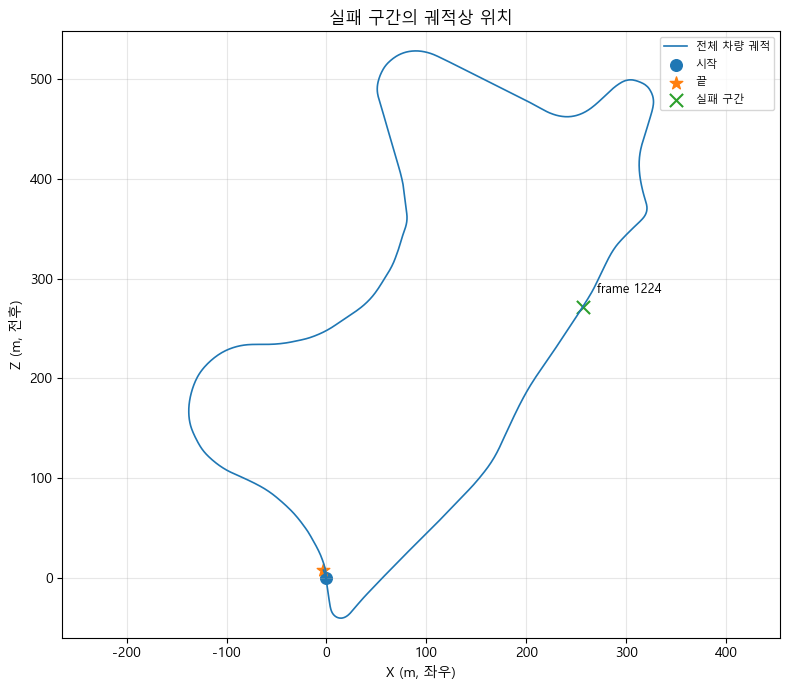

In [28]:
# 실패 프레임을 차량 궤적 위에 표시

failure_frames = np.array([1224], dtype=int)  # 대표 1개만 표시

plt.figure(figsize=(8, 7))

plt.plot(x_pos, z_pos, linewidth=1.2, label="전체 차량 궤적")
plt.scatter(x_pos[0], z_pos[0], s=70, marker="o", label="시작")
plt.scatter(x_pos[-1], z_pos[-1], s=90, marker="*", label="끝")

plt.scatter(
    x_pos[failure_frames],
    z_pos[failure_frames],
    s=90,
    marker="x",
    label="실패 구간"
)

plt.annotate(
    "frame 1224",
    (x_pos[1224], z_pos[1224]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=9
)

plt.xlabel("X (m, 좌우)")
plt.ylabel("Z (m, 전후)")
plt.title("실패 구간의 궤적상 위치")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

과다 검출 대표 프레임은 1224, 1226, 1344로 확인하였다. 이 프레임들은 차량의 전체 궤적 중 같은 주행 구간에 가까이 위치해 있었으며, 해당 구간에서 Bayesian 기반 도로 분류가 실제 도로 영역보다 넓게 나타나는 과다 검출 현상이 발생하였다. 세 프레임의 위치가 궤적상에서 서로 가깝기 때문에, 그래프에서는 대표 프레임 1224를 실패 구간의 위치로 표시하였다.

### 5-4. 실패 원인 분석

분석 결과, 실패 후보는 전체 프레임 중 일부 구간에서 나타났으며, 대부분은 도로 영역이 실제보다 넓게 검출된 과다 검출 사례였다. 대표 프레임인 1224, 1226, 1344에서는 도로 주변의 그림자, 밝은 벽면, 차량, 보도 경계 등이 함께 나타났다. 이러한 영역들은 실제 도로는 아니지만 도로와 비슷한 밝기값을 가지기 때문에 Bayesian 분류 과정에서 도로로 잘못 판단될 수 있다.

Bayesian 기반 분류는 주로 픽셀의 밝기 분포를 이용하여 도로와 배경을 구분한다. 따라서 조명 변화가 크거나 그림자가 강한 경우, 같은 도로라도 밝기가 달라질 수 있고 반대로 도로가 아닌 영역도 도로와 비슷한 밝기로 보일 수 있다. 이 때문에 밝은 구조물이나 차량 주변 영역이 도로 영역에 함께 포함되면서 과다 검출이 발생한 것으로 보인다.

또한 도로의 질감 변화도 영향을 준다. 아스팔트의 밝기, 차선 표시, 보도와 도로의 경계, 그림자에 의해 도로 픽셀의 분포가 일정하지 않게 나타날 수 있다. 이 경우 하나의 밝기 기준만으로 도로와 비도로 영역을 안정적으로 구분하기 어렵다.

차량이 회전하거나 커브 구간을 지나는 경우에도 분류가 불안정해질 수 있다. 도로가 영상 안에서 차지하는 위치와 모양이 달라지기 때문에, 미리 정한 사다리꼴 형태의 분석 영역이 실제 도로 위치와 정확히 맞지 않을 수 있다. 특히 커브 구간에서는 도로가 영상 중앙 아래쪽에 항상 같은 형태로 나타난다고 보기 어렵다.

| 원인 | 설명 |
|---|---|
| 조명 변화와 그림자 | 그림자나 밝은 영역 때문에 도로와 배경의 밝기 차이가 작아질 수 있음 |
| 도로 질감 변화 | 아스팔트 밝기, 차선 표시, 보도 경계 등이 프레임마다 다르게 나타남 |
| 차량의 회전 또는 커브 | 차량 방향이 바뀌면 영상에서 도로의 위치와 모양도 달라질 수 있음 |
| ROI 가정의 한계 | 도로가 항상 영상 아래쪽의 사다리꼴 영역에 있다고 보기 어려움 |

결론적으로 이번 실패 구간에서는 밝기 기반 Bayesian 분류의 한계와 ROI 가정의 한계가 함께 나타난 것으로 볼 수 있다. 개선 방안으로는 분석 영역을 상황에 따라 조정하거나, 밝기값뿐 아니라 색상 정보, 주변 픽셀의 형태, 차선의 방향 정보 등을 함께 사용하는 방법을 생각해 볼 수 있다.

---

## 결론

본 과제에서는 KITTI Odometry Sequence 09를 이용하여 Bayesian 기반 도로 검출, projection matrix 해석, 3D 점 투영, pose 기반 궤적 시각화, projection matrix를 활용한 차선 후보 해석, 실패 구간 분석을 수행하였다.

먼저 Bayesian 도로 분류 코드를 적용하여 grayscale 영상에서 도로 mask와 overlay 결과를 생성하였다. 이후 `calib.txt`의 `P0`를 분해하여 intrinsic parameter인 $f_x$, $f_y$, $c_x$, $c_y$의 의미를 확인하였고, projection matrix가 3D 점을 2D 이미지 좌표로 변환하는 과정을 직접 계산하였다. 3D 점 투영 결과에서는 깊이가 증가할수록 점이 광학 중심에 가까워지는 원근 효과를 확인할 수 있었다. 또한 $Z \leq 0$인 점이나 이미지 경계를 벗어나는 점은 실제 시각화에서 제외해야 함을 확인하였다.

Pose 데이터에서는 각 프레임의 평행이동 벡터를 추출하여 차량의 이동 궤적을 시각화하였다. 궤적 결과를 통해 차량이 전체적으로 전방 방향으로 이동하면서 일부 구간에서는 좌우 방향 변화도 함께 나타나는 것을 확인하였다. 또한 프레임별 이동 거리와 누적 이동 거리를 계산하여 차량의 속도가 일정하지 않고 주행 구간에 따라 달라지는 것을 확인하였다.

Bayesian 기반 도로 분류 결과에서는 도로 후보 영역을 이용하여 선분 후보를 검출하고, 이를 차선이나 도로 경계와 관련지어 해석하였다. 이미지에서 검출된 선분은 픽셀 좌표로 표현되지만, 카메라 내부 파라미터와 도로 평면 가정을 이용하면 차량 기준 좌우 및 전방 방향에서의 위치를 대략적으로 이해할 수 있었다. 또한 실제 도로 위의 차선은 거의 평행하지만, 이미지에서는 원근 효과로 인해 위쪽으로 갈수록 서로 가까워지고 소실점 방향으로 모이는 형태로 나타남을 확인하였다.

마지막으로 도로 분류가 잘 되지 않은 실패 구간을 분석하였다. 이번 결과에서는 과소 검출보다는 과다 검출이 주로 나타났으며, 실패 원인으로는 조명 변화와 그림자, 도로 질감 변화, 차량의 회전 또는 커브, 사다리꼴 ROI 가정의 한계가 영향을 준 것으로 보인다. 특히 Bayesian 분류는 주로 밝기 정보를 이용하기 때문에, 도로와 비슷한 밝기를 가진 차량 주변 영역이나 벽면, 그림자 등이 도로로 잘못 분류될 수 있음을 확인하였다.

결과적으로 이번 과제를 통해 projection matrix를 이용한 3D-2D 투영, pose 데이터를 이용한 차량 궤적 분석, 그리고 Bayesian 기반 도로 분류의 장점과 한계를 함께 확인할 수 있었다. Bayesian 방식은 별도의 학습 없이 비교적 빠르게 도로 영역을 추정할 수 있다는 장점이 있지만, 주로 밝기 정보에 의존하기 때문에 조명 변화나 복잡한 도로 환경에서는 한계가 있었다. 이후에는 소실점 기준으로 도로 후보 영역을 더 정교하게 조정하거나, 색상 정보와 주변 픽셀의 형태, 차선 방향 정보를 함께 사용하는 방법을 적용하면 더 안정적인 결과를 얻을 수 있을 것으로 보인다. 더 나아가 LaneNet과 같은 딥러닝 기반 차선 segmentation 모델과 결과를 비교해 보는 것도 의미 있을 것으로 생각된다.
